# Notebook 1: Convergence of the time-mean zonal-mean diagnostic

For a single barotropic simulation, detect spinup_time from the global enstrophy series, take the diagnostic $D(t_s, M)$ (time-mean zonal-mean of $u$ over the post-spinup window) as the long-run reference, and plot the area-weighted relative L2 error of $D(t_s, t_s+i)$ against $i$. Mark the convergence_time $t_c$ where the error first drops below CONVERGENCE_THRESHOLD and stays below for HOLD consecutive steps.

All computations come from `ml.diagnostics`: `compute_enstrophy`, `find_spinup_time`, `compute_time_mean_zonal_mean`, `area_l2_norm`.

In [1]:
SIM_DIR = "../../output/barotropic_stirring-T85/simulations/0"
CONVERGENCE_THRESHOLD = 0.05
HOLD = 3
N_FRAMES = 10

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

from ml.cmd.rotating_globe import load_data
from ml.diagnostics import (
    area_l2_norm,
    compute_enstrophy,
    compute_time_mean_zonal_mean,
    find_spinup_time,
)

In [3]:
ds = load_data(SIM_DIR)
vor = ds.vor.values
u = ds.ucomp.values
lat = ds.lat.values
M = vor.shape[0]
print(f"Loaded: M = {M}, grid {len(lat)} x {ds.sizes['lon']}")

Loaded: M = 105, grid 128 x 256


spinup_time = 9


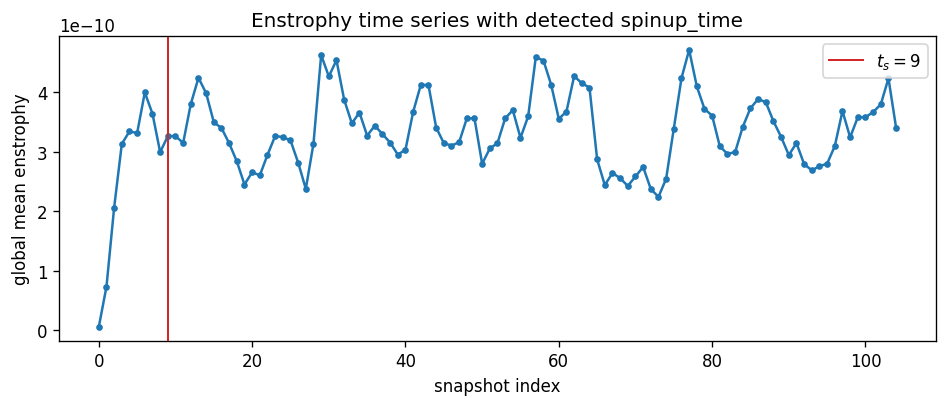

In [4]:
enstrophy = compute_enstrophy(vor, lat)
spinup_time = find_spinup_time(enstrophy)
print(f"spinup_time = {spinup_time}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(enstrophy, marker="o", markersize=3)
ax.axvline(spinup_time, color="C3", linestyle="-", linewidth=1.2, label=rf"$t_s = {spinup_time}$")
ax.set_xlabel("snapshot index")
ax.set_ylabel("global mean enstrophy")
ax.set_title("Enstrophy time series with detected spinup_time")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
diagnostic_reference = compute_time_mean_zonal_mean(u, spinup_time, M)
ref_norm = area_l2_norm(diagnostic_reference, lat)

i_values = np.arange(1, M - spinup_time)
errors = np.empty(len(i_values))
for k, i in enumerate(i_values):
    diagnostic_i = compute_time_mean_zonal_mean(u, spinup_time, spinup_time + i)
    errors[k] = area_l2_norm(diagnostic_i - diagnostic_reference, lat) / ref_norm

In [6]:
below = errors < CONVERGENCE_THRESHOLD
convergence_time = None
for start in range(len(below) - HOLD + 1):
    if below[start : start + HOLD].all():
        convergence_time = start + 1
        break
print(f"convergence_time = {convergence_time}")

convergence_time = 89


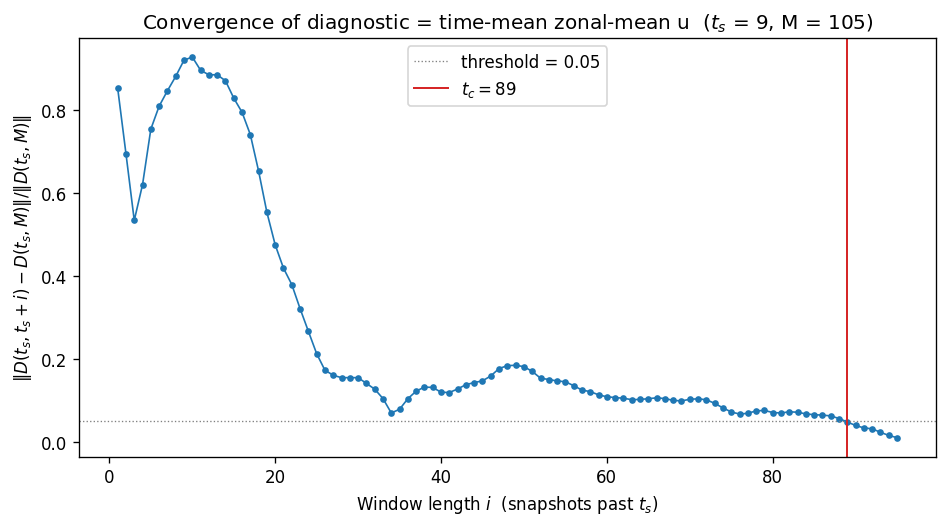

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(i_values, errors, marker="o", markersize=3, linewidth=1)
ax.axhline(CONVERGENCE_THRESHOLD, color="gray", linestyle=":", linewidth=0.8, label=f"threshold = {CONVERGENCE_THRESHOLD}")
if convergence_time is not None:
    ax.axvline(convergence_time, color="C3", linestyle="-", linewidth=1.2, label=rf"$t_c = {convergence_time}$")
ax.set_xlabel(r"Window length $i$  (snapshots past $t_s$)")
ax.set_ylabel(r"$\| D(t_s, t_s+i) - D(t_s, M) \| / \| D(t_s, M) \|$")
ax.set_title(f"Convergence of diagnostic = time-mean zonal-mean u  ($t_s$ = {spinup_time}, M = {M})")
ax.legend()
plt.tight_layout()
plt.show()

## Evolution of the diagnostic profile

Grid of $N$ frames at evenly-spaced window lengths $i$. Each panel shows the partial-window diagnostic $D(t_s, t_s+i)$ (blue) against the reference $D(t_s, M)$ (red). Convergence appears as the blue line settling onto the red.

In [8]:
i_frames = np.linspace(1, M - spinup_time - 1, N_FRAMES).astype(int)
diagnostics_frames = np.stack([
    compute_time_mean_zonal_mean(u, spinup_time, spinup_time + i)
    for i in i_frames
])
print(f"i frames: {i_frames.tolist()}")

i frames: [1, 11, 21, 32, 42, 53, 63, 74, 84, 95]


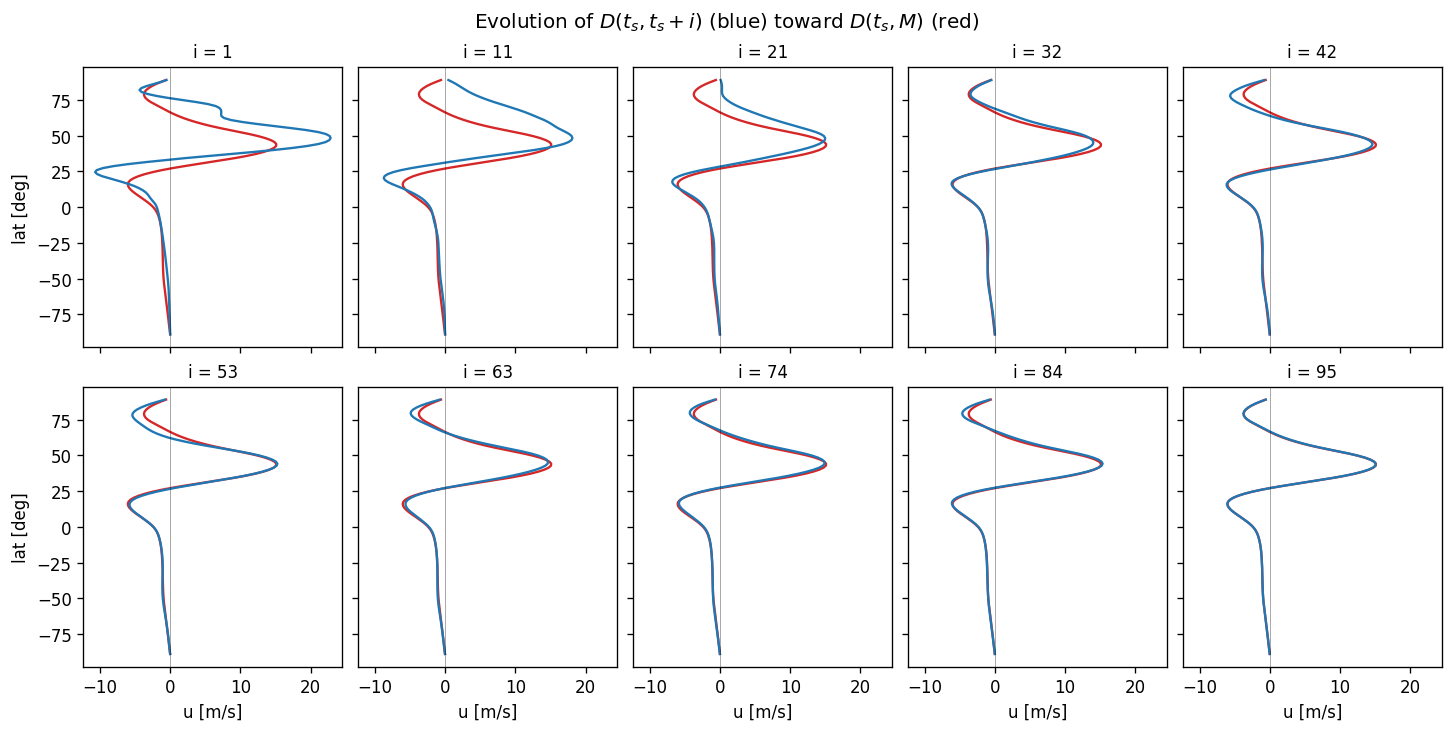

In [9]:
ncols = 5
nrows = (N_FRAMES + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 2.4, nrows * 3.0),
    sharex=True, sharey=True, constrained_layout=True,
)

for k, i in enumerate(i_frames):
    ax = axes.flat[k]
    ax.plot(diagnostic_reference, lat, color="C3", linewidth=1.4)
    ax.plot(diagnostics_frames[k], lat, color="C0", linewidth=1.4)
    ax.axvline(0.0, color="k", linewidth=0.4, alpha=0.5)
    ax.set_title(f"i = {i}", fontsize=10)
    if k % ncols == 0:
        ax.set_ylabel("lat [deg]")
    if k >= (nrows - 1) * ncols:
        ax.set_xlabel("u [m/s]")

fig.suptitle(r"Evolution of $D(t_s, t_s+i)$ (blue) toward $D(t_s, M)$ (red)")
plt.show()